In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.utilities import GoogleSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.tools import tool
from langchain.tools import Tool
from dotenv import load_dotenv
import sqlite3
import requests
import os

d:\GITHUB\Agentic-AI-Using-LangGraph\ChatBot_In_LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

# 1. LLM 
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# 2. Google Search Tool
# search = GoogleSearchAPIWrapper()

# google_search_tool = Tool(
#     name="google_search",
#     func=search.run,
#     description="Useful for answering questions about current events"
# )

In [3]:
search_tool = DuckDuckGoSearchRun(region="us-en")

# 3. Calculator Tool
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """A simple calculator tool to perform basic arithmetic operations.  

    operation must be one of:  
    - "add" ( + )  
    - "subtract" ( - )  
    - "multiply" ( * )  
    - "divide" ( / )  
    """
    try:
        if operation in ["multiply", "*"]:
            result = first_num * second_num
        elif operation in ["add", "+"]:
            result = first_num + second_num
        elif operation in ["subtract", "-"]:
            result = first_num - second_num
        elif operation in ["divide", "/"]:
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Invalid operation '{operation}'"}
        
        return {
            "first_num": first_num,
            "second_num": second_num,
            "operation": operation,
            "result": result
        }
    except Exception as e:
        return {"error": str(e)}


# 4. Stock Price Tool
@tool
def get_stock_price(symbol: str) -> dict:
    """Get the current stock price for a given symbol using AlphaVantage API."""
    api_key = os.getenv("ALPHAVANTAGE_API_KEY")
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=E2D7YACV1LYUCKNC"
    r = requests.get(url)
    return r.json()

# 5. Tools list
# tools = [google_search_tool, calculator, get_stock_price] # This was with GoogleSearchAPIWrapper
tools = [search_tool, calculator, get_stock_price]
llm_with_tools = llm.bind_tools(tools)

In [4]:
# 6. State
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
# 7. Nodes
def chat_node(state: ChatState):
    """A node that handles chat messages."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [6]:
tool_node = ToolNode(tools)

In [7]:
# 8. Checkpointer
conn = sqlite3.connect('chatbot.db', check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

In [8]:
# 9. Graph 
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges(
    "chat_node",
    tools_condition,
    {"tools": "tools", "__end__": END}
)
graph.add_edge("tools", "chat_node")


In [9]:
chatbot = graph.compile(checkpointer=checkpointer)

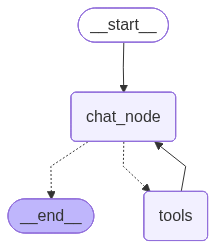

In [10]:
chatbot

In [11]:
# 10. Helper to retrieve threads
def retrieve_all_threads():
    """Retrieve all threads from the database."""
    all_threads = set()
    for checkpoint in checkpointer.list(None):
        all_threads.add(checkpoint.config['configurable']['thread_id'])
    return list(all_threads)